Change the name of the colum for later 

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('scada_data_conta_node_376_5.csv')

for column in df.columns:
    if "[CUSTOM UNIT]" in column:
        new_column_name = column.replace("[CUSTOM UNIT]", "[MG]")
        df.rename(columns={column: new_column_name}, inplace=True)
    if "CL2" in column:
        new_column_name = column.replace("CL2", "Chlorine")
        df.rename(columns={column: new_column_name}, inplace=True)

df.to_csv('scada_data_conta_node_376_5.csv', index=False)

FileNotFoundError: [Errno 2] No such file or directory: 'scada_data_conta_node_376_5.csv'

In [ ]:
import pickle


with open('..//dict_dependencies_all_1.pkl', 'rb') as f:
    loaded_dict = pickle.load(f)
print(loaded_dict)

for key, value in loaded_dict.items():
    if key == "dist423":
        print(value)
        
# for key, value in loaded_dict.items():
#     if key == "dist376":
#         print(value)

# Find the keys that have "dist1903" in their values
# keys = []
# for key, value in loaded_dict.items():
#     for element in value: 
#         if element == "dist1903":
#             keys.append(key)
# print(keys)

elements = ["dist1", "dist35", "dist106", "dist306", "dist356", "dist376", "dist423", "dist10"]

{'distTreatbefore': ['distafterTank', 'dist1', 'dist11', 'dist30', 'dist33', 'dist35', 'dist51', 'dist64', 'dist68', 'dist71', 'dist90', 'dist103', 'dist106', 'dist116', 'dist160', 'dist181', 'dist195', 'dist209', 'dist225', 'dist284', 'dist288', 'dist289', 'dist295', 'dist306', 'dist310', 'dist330', 'dist348', 'dist356', 'dist376', 'dist383', 'dist394', 'dist398', 'dist399', 'dist406', 'dist415', 'dist417', 'dist420', 'dist423', 'dist426', 'dist470', 'dist473', 'dist485', 'dist494', 'dist504', 'dist532', 'dist546', 'dist555', 'dist592', 'dist606', 'dist631', 'dist632', 'dist679', 'dist701', 'dist707', 'dist708', 'dist745', 'dist759', 'dist865', 'dist932', 'dist989', 'dist996', 'dist1001', 'dist1028', 'dist1039', 'dist1081', 'dist1130', 'dist1144', 'dist1196', 'dist1202', 'dist1225', 'dist1226', 'dist1229', 'dist1245', 'dist1268', 'dist1294', 'dist1303', 'dist1308', 'dist1309', 'dist1311', 'dist1332', 'dist1339', 'dist1345', 'dist1346', 'dist1363', 'dist1367', 'dist1371', 'dist1372', '

In [34]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.cluster import KMeans

def get_interesting_and_similar_nodes(df, contaminated_node, dependencies_dict_path, cluster_number):
    with open(dependencies_dict_path, 'rb') as f:
        dependencies_dict = pickle.load(f)
    interesting_nodes = dependencies_dict[contaminated_node]
    
    time_series_data = get_times_series(df, interesting_nodes)
    
    X = np.array(list(time_series_data.values())) 
    kmeans = KMeans(n_clusters=cluster_number, random_state=0, n_init="auto").fit_predict(X)

    # Group nodes by their assigned cluster
    cluster_nodes = {}
    for i in range(len(kmeans)):
        cluster = kmeans[i]
        node = interesting_nodes[i]
        if cluster not in cluster_nodes:
            cluster_nodes[cluster] = []
        cluster_nodes[cluster].append(node)
        
    return cluster_nodes

def get_times_series(df, nodes): 
    time_series_data = {}
    for node in nodes:
        column_name_cl = f"bulk_species_node [MG] at chlorine @ {node}"
        if column_name_cl in df.columns:
            time_series_data[node] = df[column_name_cl].values
    return time_series_data

def plot_time_series(time_series_data, node):
    plt.plot(time_series_data[node])
    plt.title(f"Time series for node {node}")
    plt.xlabel("Time")
    plt.ylabel("Chlorine concentration [MG]")
    plt.show()

{np.int32(3): ['dist1', 'dist348', 'dist470', 'dist606', 'dist632', 'dist759', 'dist865', 'dist1454', 'dist1455', 'dist1496', 'dist1528', 'dist1539', 'dist1568', 'dist1611', 'dist1722', 'dist1840', 'dist1843'], np.int32(4): ['dist11', 'dist35', 'dist195', 'dist394', 'dist426', 'dist485', 'dist494', 'dist532', 'dist1634', 'dist1808', 'dist1850', 'dist1973', 'dist1979', 'dist1984'], np.int32(1): ['dist30', 'dist33', 'dist68', 'dist71', 'dist116', 'dist225', 'dist546', 'dist555', 'dist592', 'dist1039', 'dist1081', 'dist1656', 'dist1741', 'dist1765', 'dist1869', 'dist1962', 'dist1975'], np.int32(2): ['dist51', 'dist103', 'dist399', 'dist631', 'dist679', 'dist707', 'dist1144', 'dist1294', 'dist1308', 'dist1332', 'dist1339', 'dist1346', 'dist1468', 'dist1502', 'dist1608', 'dist1702', 'dist1723', 'dist1788', 'dist1915', 'dist1936', 'dist1944'], np.int32(0): ['dist106', 'dist306', 'dist356', 'dist376', 'dist398', 'dist415', 'dist473', 'dist932', 'dist1028', 'dist1345', 'dist1363', 'dist1367', 

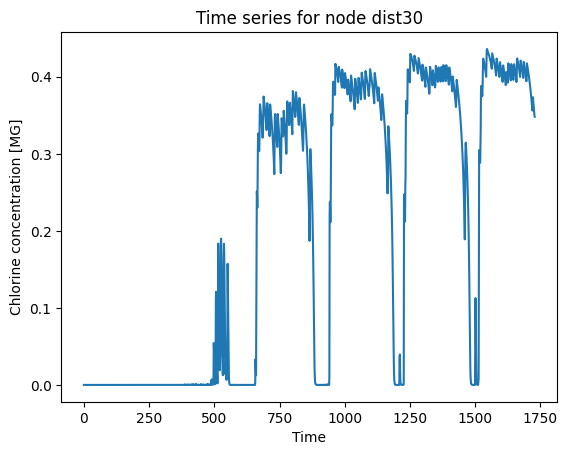

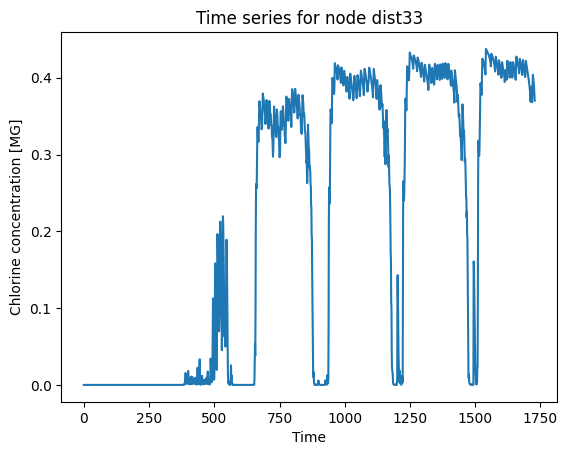

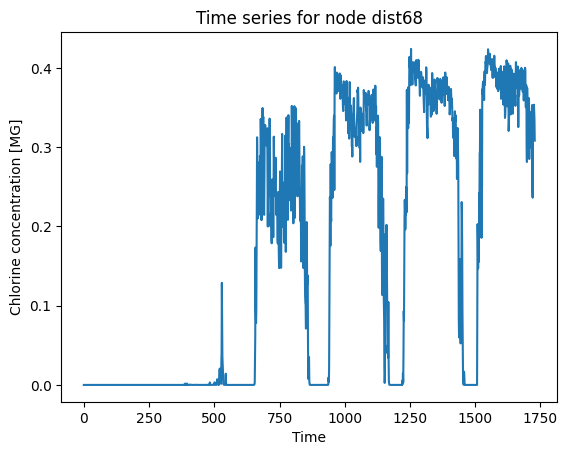

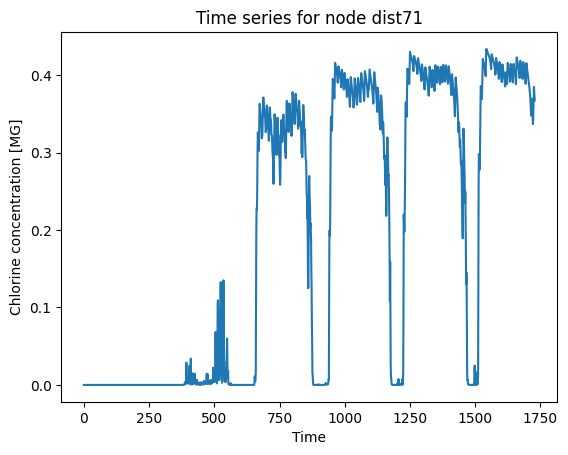

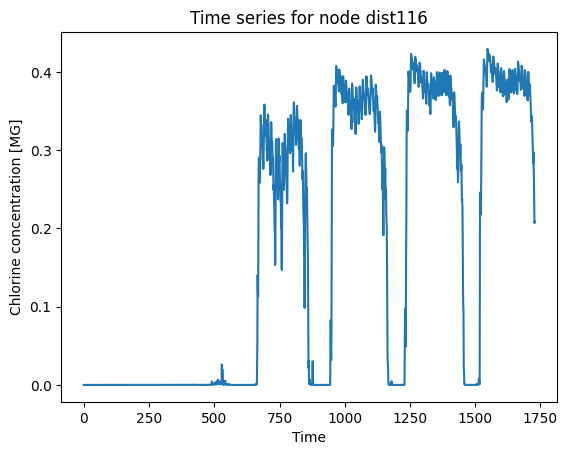

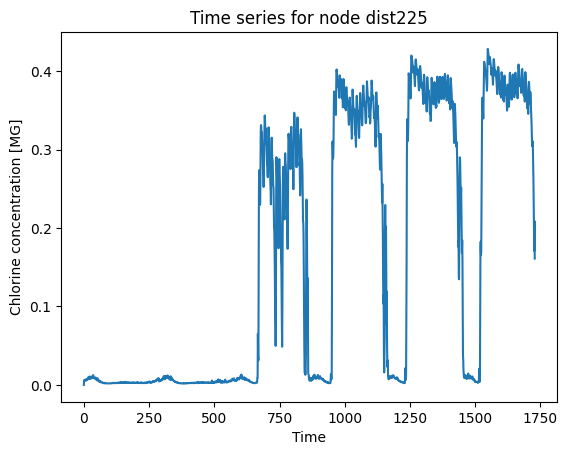

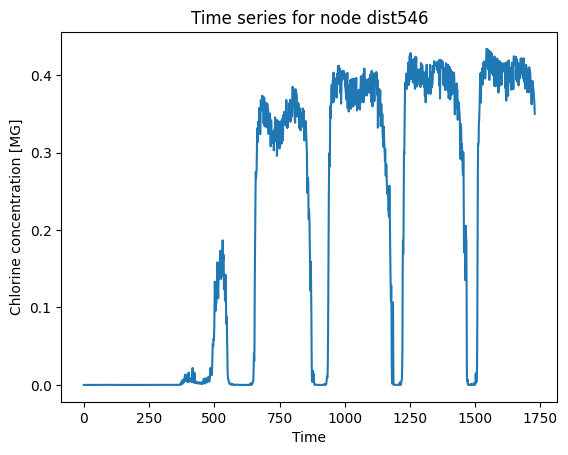

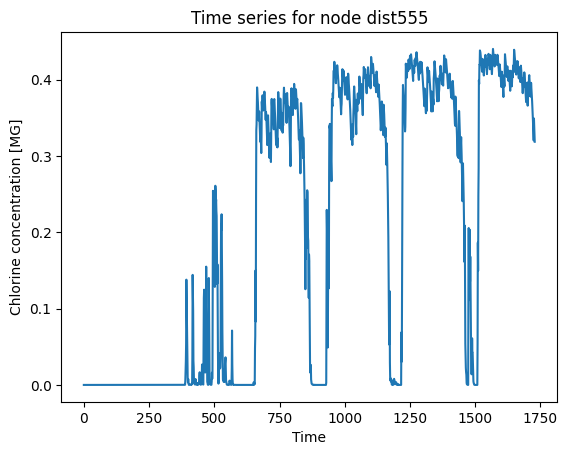

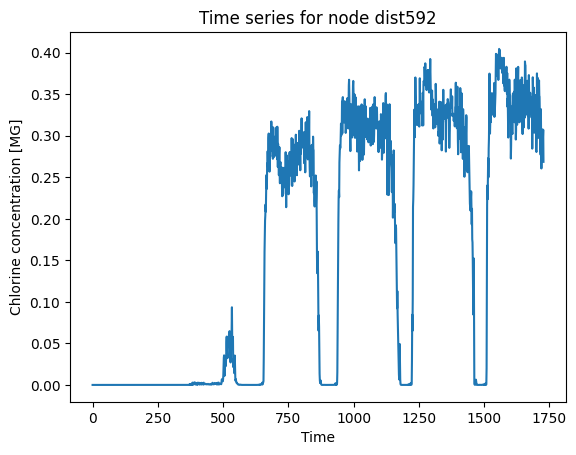

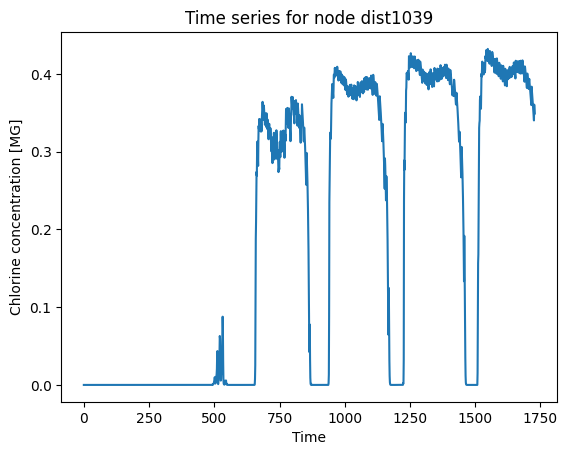

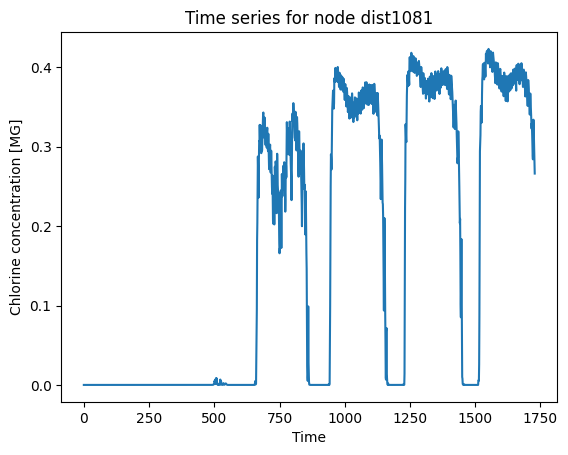

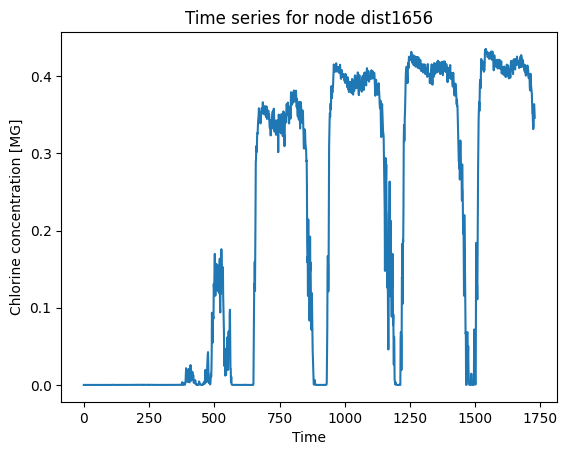

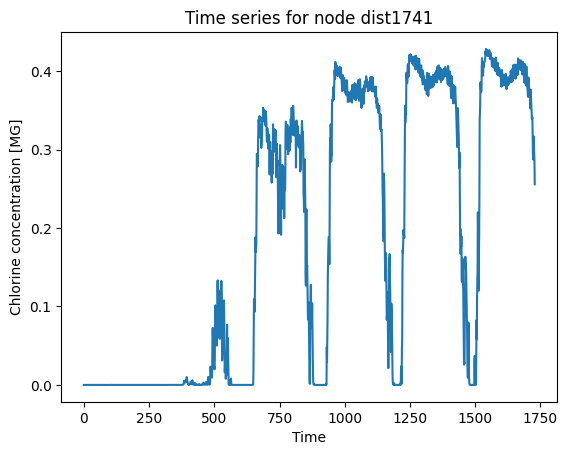

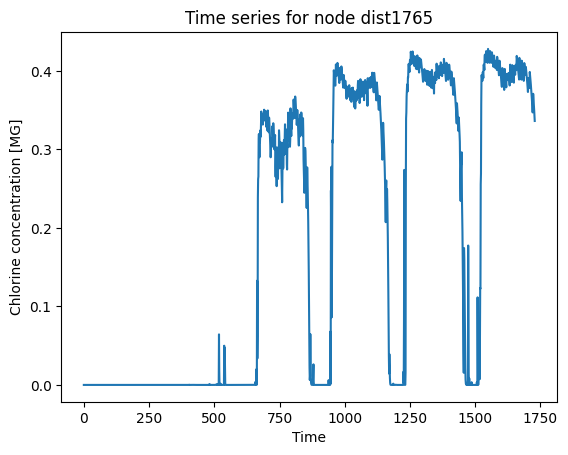

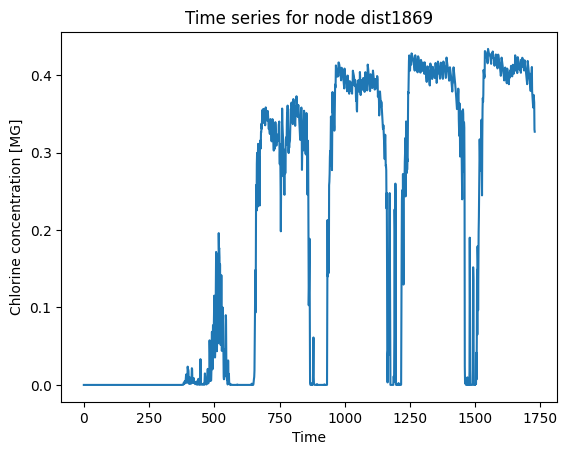

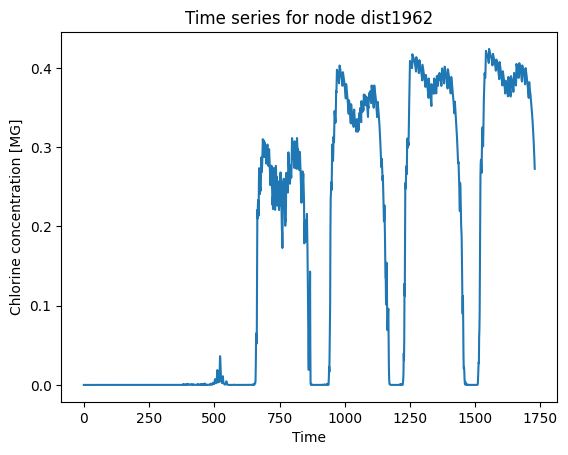

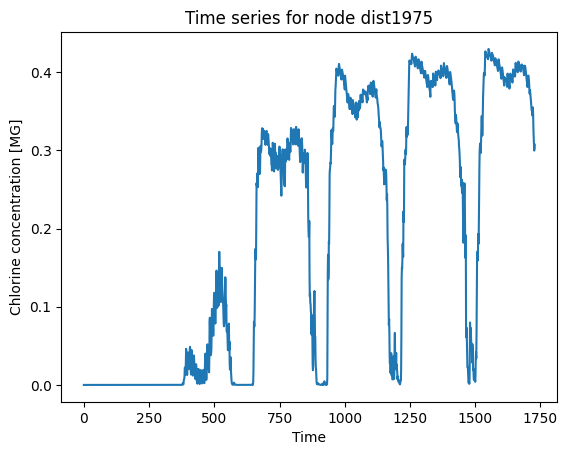

In [48]:
df = pd.read_csv('scada_data_clean.csv')

dic = get_interesting_and_similar_nodes(df, "dist423", '..//dict_dependencies_significant_nodes.pkl', 5)
print(dic)

time_series = get_times_series(df, dic[1])
for node in time_series.keys():
    plot_time_series(time_series, node)